# All Process
## 1. 2차원 이미지에서 object detection and crop + camera intrinsic 
### PIDNet(segmentatino)
## 2. croped image에서 2차원 pose estimation (HUMAN & ROBOT)
### encoder decoder architecture / YOLO11 / RTMpose
## 3. 2차원 pose 값을 통한 3차원 pose estimation
### Robokeygen / Gfpose

# 1. Object detection model
### PIDNet을 통한 segmentation & background remove

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import cv2
import numpy as np
from PIL import Image

from ultralytics import YOLO
from ultralytics import SAM
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU 사용 가능 여부 확인

(720, 930)


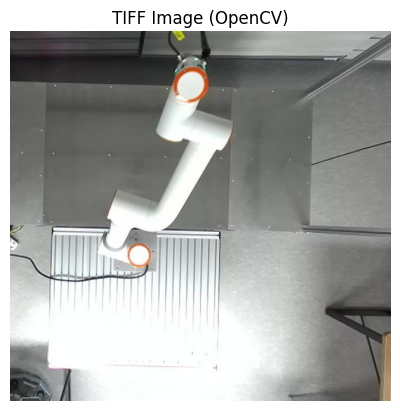

In [2]:
# # 이미지 로드
image_path = "/home/najo/NAS/DIP/datasets/FR5_model/YOLO_Train/images/train/image0.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def crop_center(img, target_width, target_height):
    # 원본 이미지 크기
    orig_shape = img.shape[:2]  # (height, width)
    height, width = orig_shape

    # 크롭할 영역의 시작점 계산 (가운데 기준)
    start_x = (width - target_width) // 2
    start_y = (height - target_height) // 2

    # 이미지를 크롭
    cropped_img = img[start_y:start_y + target_height, start_x:start_x + target_width]
    return cropped_img


# orig_shape = img.shape[:2]
# print(orig_shape)

# TIFF 이미지 불러오기 (OpenCV는 BGR 포맷으로 읽음)
# tiff_image_path = "/home/najo/NAS/DIP/datasets/Robot_data/Basler_acA1300-30gc__24051641__20240911_150924559_0569.tiff"  # TIFF 파일 경로
# tiff_image = cv2.imread(tiff_image_path, cv2.IMREAD_UNCHANGED)

# 이미지 정보 출력
# print("Shape:", tiff_image.shape)  # (높이, 너비, 채널)
# print("Data Type:", tiff_image.dtype)  # 데이터 타입

# 이미지 표시 (BGR을 RGB로 변환)
orig_shape = img.shape[:2]
print(orig_shape)

input_size = (720, 700)
img = crop_center(img, *input_size)

plt.imshow(img)
plt.axis('off')
plt.title('TIFF Image (OpenCV)')
plt.show()

In [3]:
# 모델 로드 및 GPU 이동
model = SAM("/home/najo/NAS/DIP/sam_l.pt").to(device)

# 모델 입력 크기 확인 (예: 1024x1024 가정)
input_size = (1024, 1024)

# 이미지 리사이즈 및 정규화
resized_img = cv2.resize(img, input_size)
img_tensor = torch.from_numpy(resized_img).permute(2, 0, 1).unsqueeze(0).float() / 255.0  # 정규화
img_tensor = img_tensor.to(device)  # GPU로 이동

# 추론 실행
segmentation = model(img_tensor)


0: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 6060.4ms
Speed: 0.0ms preprocess, 6060.4ms inference, 3.2ms postprocess per image at shape (1, 3, 1024, 1024)


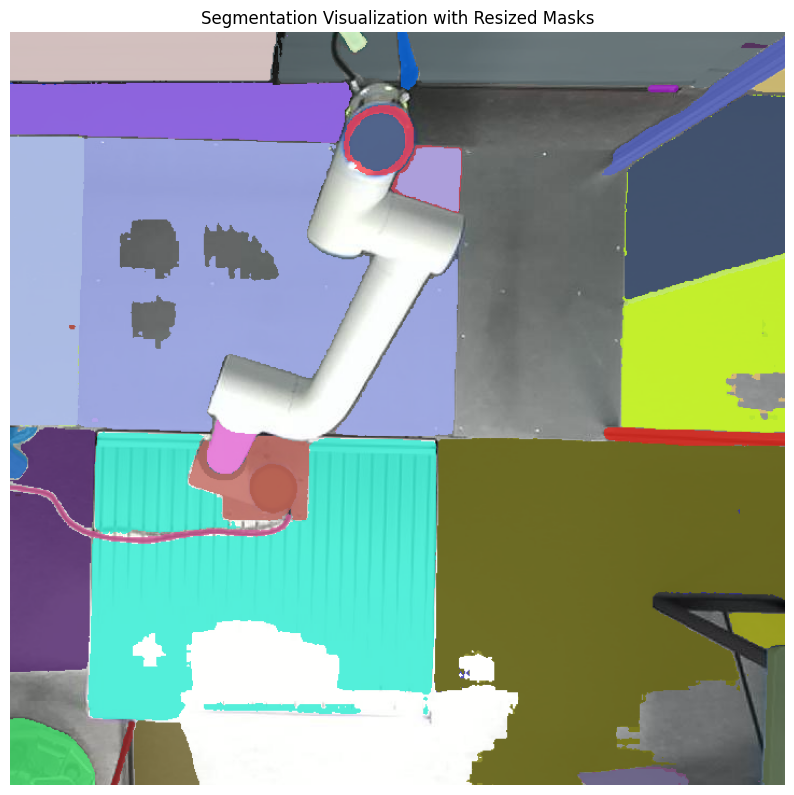

In [5]:
masks = segmentation[0].masks.data.cpu().numpy()  # 마스크 데이터 (N x H x W 형태)
orig_shape = img.shape[:2]  # 원본 이미지 크기 (H, W)

# 마스크를 원본 크기로 리사이즈 (bool -> uint8로 변환)
resized_masks = np.array([
    cv2.resize(mask.astype(np.uint8), (orig_shape[1], orig_shape[0]), interpolation=cv2.INTER_NEAREST) 
    for mask in masks
])

# 마스크를 원본 이미지 위에 덧씌우기
visualized_img = img.copy()

# 마스크 시각화를 위한 색상 정의
colors = np.random.randint(0, 255, size=(resized_masks.shape[0], 3), dtype=np.uint8)  # N개의 랜덤 색상 생성

for i, mask in enumerate(resized_masks):
    color = colors[i]  # 객체마다 다른 색상
    mask_indices = mask > 0  # 마스크의 유효 부분만 추출
    visualized_img[mask_indices] = 0.2 * visualized_img[mask_indices] + 0.8 * color  # 마스크 색상 혼합

# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(visualized_img, cv2.COLOR_BGR2RGB))  # BGR -> RGB로 변환
plt.axis('off')
plt.title('Segmentation Visualization with Resized Masks')
plt.show()

In [10]:
# # 배경 제거: 원본 이미지에 마스크 적용
# object_only = cv2.bitwise_and(img, img, mask=resized_masks.astype(np.uint8))

# binary_mask = (resized_masks > 0).astype(np.uint8)
# x, y, w, h = cv2.boundingRect(binary_mask)
# cropped_img = object_only[y:y+h, x:x+w]

# # 시각화
# plt.figure(figsize=(12, 8))

# plt.subplot(1, 4, 1)
# plt.title("Original Image")
# plt.imshow(img)
# plt.axis("off")

# plt.subplot(1, 4, 2)
# plt.title("Segmentation Mask")
# plt.imshow(mask, cmap="gray")
# plt.axis("off")

# plt.subplot(1, 4, 3)
# plt.title("Object Only")
# plt.imshow(object_only)
# plt.axis("off")

# plt.subplot(1, 4, 4)
# plt.title("Cropped Image")
# plt.imshow(cropped_img)
# plt.axis("off")

# plt.show()


0: 640x640 1 person, 6.2ms
Speed: 3.3ms preprocess, 6.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


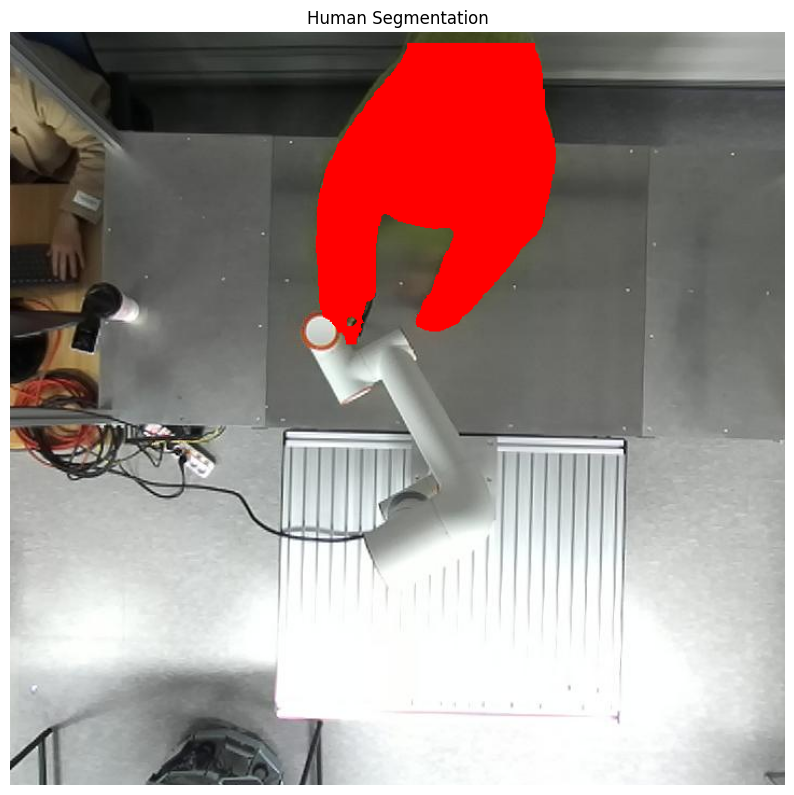

In [39]:
# 모델 로드
model = YOLO('/home/najo/NAS/DIP/yolov8n-seg.pt')  # YOLOv8 세그멘테이션 모델

# 모델 추론
results = model(img)

# Human 클래스만 필터링
human_class_id = 0  # COCO 데이터셋 기준으로 "human" 클래스 ID는 0 (다른 데이터셋에서는 확인 필요)
human_masks = []
for i, box in enumerate(results[0].boxes):
    if box.cls == human_class_id:  # 클래스 ID가 human인 경우
        human_masks.append(results[0].masks.data[i].cpu().numpy())  # 해당 객체의 마스크 저장

# Human 마스크 시각화
if human_masks:
    visualized_img = img.copy()

    for mask in human_masks:
        mask_resized = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        visualized_img[mask_resized > 0.5] = [255, 0, 0]  # Red 색상으로 표시 (BGR)

    plt.figure(figsize=(10, 10))
    plt.imshow(visualized_img)
    plt.axis('off')
    plt.title('Human Segmentation')
    plt.show()
else:
    print("No humans detected in the image.")


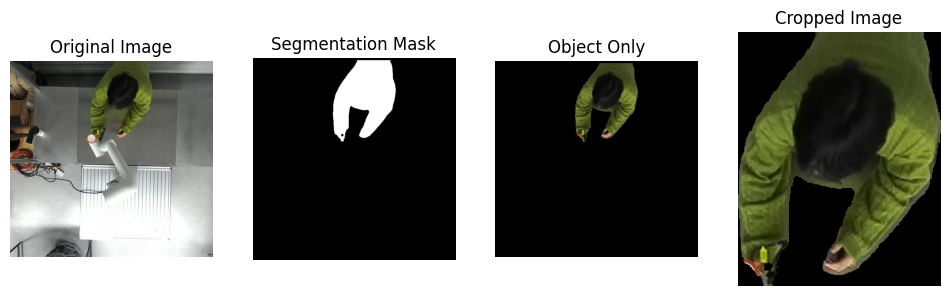

In [40]:
# 배경 제거: 원본 이미지에 마스크 적용
object_only = cv2.bitwise_and(img, img, mask=mask_resized.astype(np.uint8))

binary_mask = (mask_resized > 0).astype(np.uint8)
x, y, w, h = cv2.boundingRect(binary_mask)
cropped_img = object_only[y:y+h, x:x+w]

# 시각화
plt.figure(figsize=(12, 8))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Segmentation Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Object Only")
plt.imshow(object_only)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Cropped Image")
plt.imshow(cropped_img)
plt.axis("off")

plt.show()


0: 640x640 1 person, 1 bicycle, 7.7ms
Speed: 2.5ms preprocess, 7.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


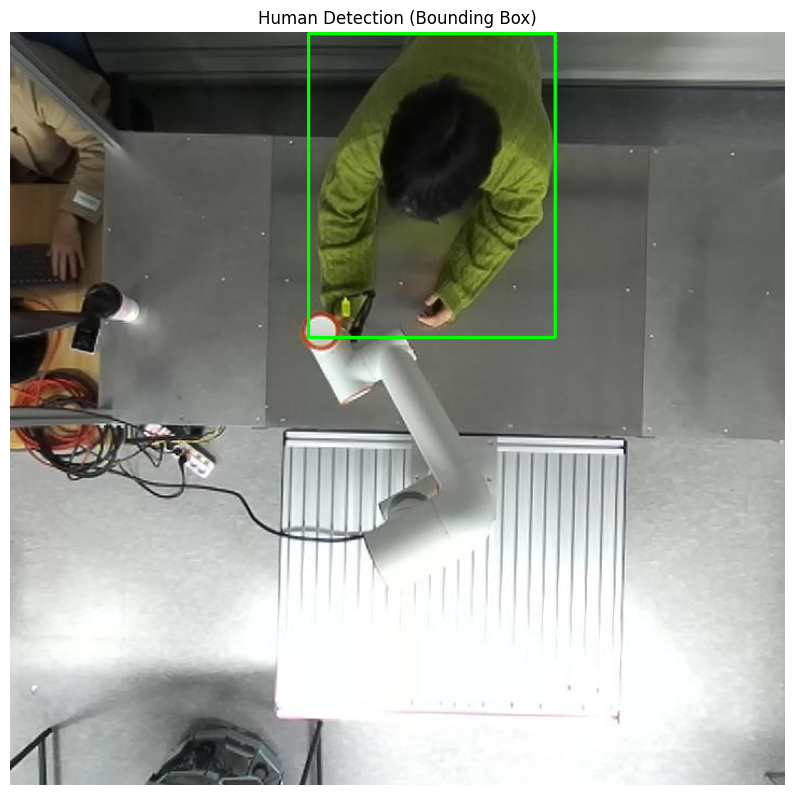

In [41]:
# 모델 로드
model = YOLO('/home/najo/NAS/DIP/yolo11n.pt')  # YOLOv8 모델 (n: Nano, s: Small 등 크기에 따라 변경 가능)

# 모델 추론
results = model(img)

# Human 클래스만 필터링
human_class_id = 0  # COCO 데이터셋 기준 "human" 클래스 ID
boxes = results[0].boxes.data.cpu().numpy()  # 박스 데이터 (x1, y1, x2, y2, confidence, class)

human_boxes = [box for box in boxes if int(box[5]) == human_class_id]  # Human 클래스 필터링

# Bounding Box 시각화
visualized_img = img.copy()
for box in human_boxes:
    x1, y1, x2, y2, conf, cls = box
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
    conf = round(conf, 2)

    # 박스 그리기
    cv2.rectangle(visualized_img, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=2)  # 초록색 박스

    # 클래스 및 신뢰도 표시
    cv2.putText(
        visualized_img,
        f"Human: {conf}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        2
    )

# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(visualized_img)
plt.axis('off')
plt.title('Human Detection (Bounding Box)')
plt.show()

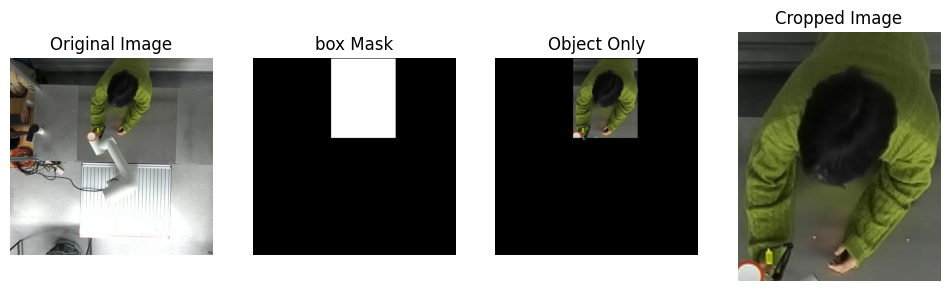

In [42]:
# Human 클래스 필터링 결과 저장
human_boxes = [box for box in boxes if int(box[5]) == human_class_id]  # Human 클래스 필터링

# Human 박스 영역만 이미지로 저장
for idx, box in enumerate(human_boxes):
    x1, y1, x2, y2, conf, cls = map(int, box)  # 좌표를 정수로 변환
    cropped_img = img[y1:y2, x1:x2]  # 박스 영역 잘라내기
    mask_resized[y1:y2, x1:x2] = 255

object_only = cv2.bitwise_and(img, img, mask=mask_resized.astype(np.uint8)  # 1인 픽셀만 남김
)

# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("box Mask")
plt.imshow(mask_resized, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Object Only")
plt.imshow(object_only)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Cropped Image")
plt.imshow(cropped_img)
plt.axis("off")

plt.show()


# 2D pose estimation model

In [ ]:
# # Load a model
# model = YOLO("yolo11n-pose.yaml")  # build a new model from YAML
# model = YOLO("yolo11n-pose.pt")  # load a pretrained model (recommended for training)
# model = YOLO("yolo11n-pose.yaml").load("yolo11n-pose.pt")  # build from YAML and transfer weights

# # Train the model
# results = model.train(data="coco8-pose.yaml", epochs=100, imgsz=640)

# # Export the model
# model.export(format="onnx")

0: 640x640 2 persons, 8.3ms
Speed: 2.4ms preprocess, 8.3ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)
keypoint xy
 [[     398.23      168.49]
 [     410.79      154.09]
 [     382.62      153.25]
 [          0           0]
 [          0           0]
 [     482.07      111.82]
 [     333.08      117.05]
 [     485.47      177.25]
 [     299.02      179.87]
 [     422.08      245.95]
 [     311.04      246.09]
 [     437.27      122.69]
 [     337.47       122.3]
 [      438.1      187.92]
 [     319.07      190.04]
 [     387.78      222.62]
 [     308.42      227.39]]


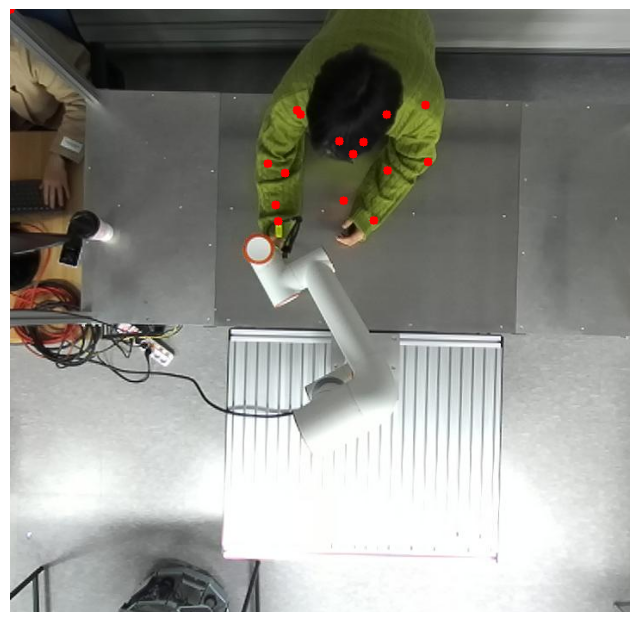

In [43]:
model = YOLO("/home/najo/NAS/DIP/yolo11n-pose.pt")

results = model.predict(source=img, save=False)  # predict on an image
keypoints_2d = results[0].keypoints
keypoints = keypoints_2d.xy[0].cpu().numpy()  # 첫 번째 객체의 keypoints (CPU로 이동)
# Keypoints 시각화
print("keypoint xy\n", keypoints)
for keypoint in keypoints:
    x, y = keypoint
    cv2.circle(img, (int(x), int(y)), 5, (255, 0, 0), -1)  # 빨간 원으로 keypoint 표시

# 이미지를 matplotlib으로 시각화
plt.figure(figsize=(8,10))

plt.imshow(img)
plt.axis('off')  # 축 제거
plt.show()

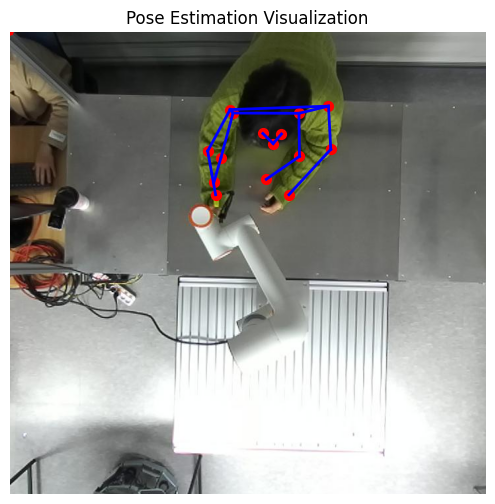

In [44]:
# 결과에서 Keypoints 가져오기 (YOLO output)
keypoints = results[0].keypoints.xy[0].cpu().numpy()  # keypoints 좌표 가져오기
confidences = results[0].keypoints.conf[0].cpu().numpy()  # confidence 가져오기

# 키포인트 연결 정의 (COCO 포맷 예시)
connections = [
    (0, 1), (0, 2), (1, 3), (2, 4),  # Head
    (5, 6),                           # Shoulders
    (5, 7), (7, 9),                   # Left Arm
    (6, 8), (8, 10),                  # Right Arm
    (11, 12),                         # Hips
    (5, 11), (6, 12),                 # Torso to Hips
    (11, 13), (13, 15),               # Left Leg
    (12, 14), (14, 16)                # Right Leg
]


# 시각화 시작
plt.figure(figsize=(8, 6))
plt.title("Pose Estimation Visualization")

# 이미지 배경 (원본 이미지 삽입)
plt.imshow(img)

# Keypoints 그리기
for idx, (x, y) in enumerate(keypoints):
    if confidences[idx] > 0.5:  # Confidence threshold
        plt.scatter(x, y, color="red", s=50, label=f"Point {idx}" if idx == 0 else "")

# 연결 그리기
for connection in connections:
    start, end = connection
    if confidences[start] > 0.5 and confidences[end] > 0.5:  # 연결된 두 키포인트 모두 신뢰성 높을 때
        x_start, y_start = keypoints[start]
        x_end, y_end = keypoints[end]
        plt.plot([x_start, x_end], [y_start, y_end], color="blue", linewidth=2)

# 결과 출력
plt.axis("off")
plt.show()


# 3D pose estimation model

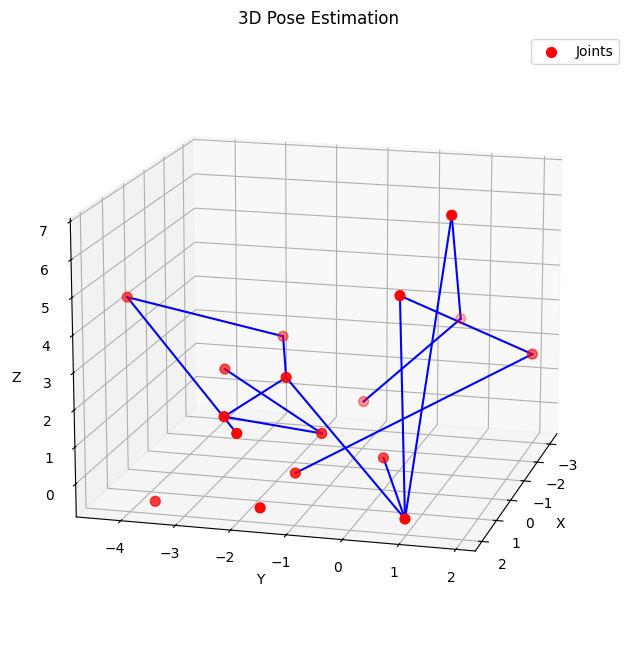

In [112]:
def plot_3d_keypoints(keypoints_3d, title="3D Keypoints", connections=None):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 축 설정
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=15, azim=15)  # 시점 조정 (elevation, azimuth)

    # 키포인트 플롯
    ax.scatter(keypoints_3d[:, 0], keypoints_3d[:, 1], keypoints_3d[:, 2], c='red', s=50, label='Joints')

    # 연결된 관절 플롯
    if connections:
        for joint1, joint2 in connections:
            ax.plot(
                [keypoints_3d[joint1, 0], keypoints_3d[joint2, 0]],
                [keypoints_3d[joint1, 1], keypoints_3d[joint2, 1]],
                [keypoints_3d[joint1, 2], keypoints_3d[joint2, 2]],
                c='blue'
            )

    # 범례와 축 스케일 고정
    ax.legend()
    ax.set_xlim([np.min(keypoints_3d[:, 0]), np.max(keypoints_3d[:, 0])])
    ax.set_ylim([np.min(keypoints_3d[:, 1]), np.max(keypoints_3d[:, 1])])
    ax.set_zlim([np.min(keypoints_3d[:, 2]), np.max(keypoints_3d[:, 2])])
    plt.show()


# 키포인트 연결 정의 (COCO 포맷 예시)
connections = [
    # Head
    (0, 1),  # Head top to Neck

    # Shoulders and Arms
    (1, 2), (2, 3), (3, 4),  # Neck to Left Arm (Shoulder -> Elbow -> Hand)
    (1, 5), (5, 6), (6, 7),  # Neck to Right Arm (Shoulder -> Elbow -> Hand)

    # Torso
    (1, 8),  # Neck to Pelvis

    # Hips and Legs
    (8, 9), (9, 10), (10, 11),  # Pelvis to Left Leg (Hip -> Knee -> Foot)
    (8, 12), (12, 13), (13, 14)  # Pelvis to Right Leg (Hip -> Knee -> Foot)
]



# 3D 키포인트 시각화 호출
plot_3d_keypoints(keypoints_3d[0], title="3D Pose Estimation", connections=connections)
